In [1]:
include("../RayTracing.jl")
using Images, ColorTypes

ArgumentError: ArgumentError: Package ImageTransformations not found in current path, maybe you meant `import/using .ImageTransformations`.
- Otherwise, run `import Pkg; Pkg.add("ImageTransformations")` to install the ImageTransformations package.

# Lantern Diffuse

In [2]:
function apply_vignette(img; center=(0.5, 0.5), inner_radius=0.3, outer_radius=0.7, strength=1.0)
    h, w = size(img)
    result = similar(img)
    
    for j in 1:w, i in 1:h
        # Convert to UV coordinates (0-1 range)
        u = (j - 0.5) / w
        v = (i - 0.5) / h
        
        # Distance from center in UV space
        dist = sqrt((u - center[1])^2 + (v - center[2])^2)
        
        # Compute vignette factor
        if dist <= inner_radius
            factor = 1.0
        elseif dist >= outer_radius
            factor = 1.0 - strength
        else
            # Smooth interpolation between inner and outer radius
            t = (dist - inner_radius) / (outer_radius - inner_radius)
            t = t * t * (3 - 2t)  # smoothstep
            factor = 1.0 - strength * t
        end
        
        result[i, j] = clamp01(img[i, j] * factor)
    end
    
    return result
end

apply_vignette (generic function with 1 method)

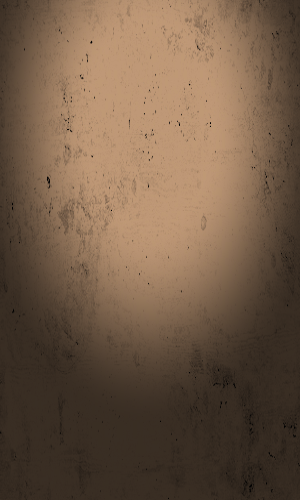

In [3]:
img = load(RayTracing.jmfp("/Users/johnmyslinski/Documents/PBRJ/ref/floating_lanterns/materials/lanterns/lantern diffuse.jpg"))

img = imresize(img, (500, 300))

img = apply_vignette(img; center=(0.5, 0.25), inner_radius=0.2, outer_radius=0.6, strength=0.7)
             
save("/Users/johnmyslinski/Documents/PBRJ/ref/floating_lanterns/materials/lanterns/lantern diffuse_JM.jpg", img)
img

# absolutely fucking not

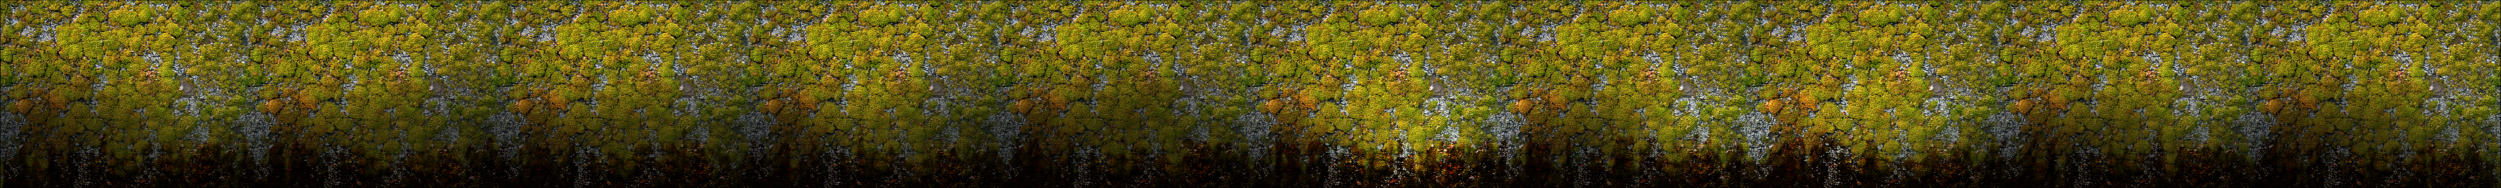

In [58]:
img = load(RayTracing.jmfp("/Users/johnmyslinski/Documents/PBRJ/ref/floating_lanterns/materials/rock wall/mossyrocksbigfix.jpg"))

old = RayTracing.Pnt2(25000, 1875)

new = RayTracing.Pnt2i(floor.(old ./ 5.0))

img = imresize(img, (new.y, new.x))

# img = apply_vignette(img; center=(0.5, 0.25), inner_radius=0.2, outer_radius=0.6, strength=0.7)
             
save("/Users/johnmyslinski/Documents/PBRJ/ref/floating_lanterns/materials/rock wall/mossyrocksbigfix_JM.jpg", img)
img

# lantern lights

In [66]:
using Images

# Create image dimensions
width, height = 800, 800
img = zeros(RGB{Float64}, height, width)

# Center point
cx, cy = width / 2, height / 2
max_dist = sqrt(cx^2 + cy^2)

# Vignette control: higher = smaller yellow center
vignette_strength = 1.0

for y in 1:height, x in 1:width
    # Normalized distance from center (0 at center, 1 at corners)
    dist = sqrt((x - cx)^2 + (y - cy)^2) / max_dist
    
    # Smooth falloff with controllable strength
    t = clamp(dist^vignette_strength, 0, 1)
    
    # Interpolate yellow (center) to red (edges)
    r = 1.0
    g = 1.0 - t
    b = 0.0
    
    img[y, x] = RGB(r, g, b)
end


In [72]:
save("/Users/johnmyslinski/Documents/PBRJ/ref/floating_lanterns/materials/lamp/lamp_light_diffuse_JM.jpg", img)

35153